# Automatic differentiation with forward mode

> **NOTE**
>
> autodiff system in `pespace` and `tiwave` is still under active development. If errors occur when running this notebook, try using the commit tagged [`autodiff`](https://github.com/nnrui/pespace/tree/autodiff) may solve the problem.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import bilby

import taichi as ti
ti.init(
    arch=ti.cpu,
    default_fp=ti.f64,
    cpu_max_num_threads=1,
    offline_cache=False,
    # debug=True,
)

import os
os.environ['PATH'] = "/home/nrui/.local/texlive/2025/bin/x86_64-linux:" + os.environ['PATH']

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19


[I 02/02/26 11:42:21.678 84923] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=x64


In [2]:
from pespace.detector.antenna import InterferometerAntenna, FDResponseModelMarset2018
from pespace.detector.tdi import TDIChannelData, FDMichelsonConstantEqualArm
from pespace.detector.orbit import available_orbit_models
from tiwave.waveforms import IMRPhenomXAS


In [3]:
tdi_gen = "2.0"
tdi_chan = ("A", "E", "T")
DAYJUL_SI = 86400.0

delta_time = 10
num_tsamples = 2 ** np.ceil(np.log2(7 * DAYJUL_SI / delta_time))
duration = num_tsamples * delta_time
print("sample num: ", num_tsamples)
print("duration: ", duration)
print("duration(day): ", duration/DAYJUL_SI)

f_min = 1e-4
f_ref = f_min
f_max = 0.5*(1/delta_time)

t_start = 0.0
before_tc = 0.8 * duration
after_tc = 0.2 * duration
tc = t_start + before_tc

params = dict(
    total_mass=3e6,
    mass_ratio=0.6,
    chi_1=0.75,
    chi_2=0.62,
    luminosity_distance=56000.0,
    inclination=0.4,
    reference_phase=1.3,
    ecliptic_longitude=1.375,
    ecliptic_latitude=-1.2108,
    polarization=2.659,
    coalescence_time=tc,
)
params = bilby.gw.conversion.generate_mass_parameters(params)
print(params)

sample num:  65536.0
duration:  655360.0
duration(day):  7.5851851851851855
{'total_mass': 3000000.0, 'mass_ratio': 0.6, 'chi_1': 0.75, 'chi_2': 0.62, 'luminosity_distance': 56000.0, 'inclination': 0.4, 'reference_phase': 1.3, 'ecliptic_longitude': 1.375, 'ecliptic_latitude': -1.2108, 'polarization': 2.659, 'coalescence_time': np.float64(524288.0), 'mass_1': 1875000.0, 'mass_2': 1125000.0, 'chirp_mass': 1256226.717491785, 'symmetric_mass_ratio': np.float64(0.234375)}


In [4]:
tdi_data = TDIChannelData()
tdi_data.set_fd_data_from_zero(
    tdi_chan,
    duration,
    delta_time,
    start_time=t_start,
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)

orbit_model = available_orbit_models['LISA_analytic']
response_model = FDResponseModelMarset2018()
tdi_combination = FDMichelsonConstantEqualArm(generation=tdi_gen, orthogonal=True)

lisa = InterferometerAntenna(
    name="lisa",
    tdi_data=tdi_data,
    orbit_model=orbit_model,
    response_model=response_model,
    tdi_combination=tdi_combination,
    needs_dual=True,
)
waveform_tiw = IMRPhenomXAS(
    tdi_data.frequency_samples, 
    f_ref, 
    )
waveform_tiw.update_waveform(params)
lisa.update_detector_response(
    waveform_tiw.waveform_container,
    params['ecliptic_longitude'],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:74: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


In [5]:
# # abs
# plt.figure()
# plt.loglog(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     np.abs(lisa.tdi_response_numpy["A"]),
#     label="A",
# )
# plt.loglog(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     np.abs(lisa.tdi_response_numpy["E"]),
#     label="E",
# )
# plt.loglog(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     np.abs(lisa.tdi_response_numpy["T"]),
#     label="T",
# )
# plt.xlim(f_min, f_max)
# plt.legend()

# # real part
# plt.figure()
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["A"].real,
#     label="A real",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["E"].real,
#     label="E real",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["T"].real,
#     label="T real",
# )
# plt.xlim(f_min, f_max)
# plt.legend()

# # imag part
# plt.figure()
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["A"].imag,
#     label="A imag",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["E"].imag,
#     label="E imag",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["T"].imag,
#     label="T imag",
# )
# plt.xlim(f_min, f_max)
# plt.legend()

In [6]:
field_names = [
    'link12_re', 
    'link12_im', 
    'link21_re', 
    'link21_im', 
    'link23_re', 
    'link23_im', 
    'link32_re', 
    'link32_im', 
    'link31_re', 
    'link31_im', 
    'link13_re', 
    'link13_im', 
    ]
loss = {key: ti.field(dtype=ti.f64, shape=tdi_data.frequency_samples.shape, needs_dual=True) for key in field_names}
# print(loss)
# print(loss['link12_re'])

# @ti.kernel
# def test():
#     print(ti.get_addr(loss['link12_re'], 0))
#     print(ti.get_addr(loss['link12_im'], 0))
#     print(ti.get_addr(loss['link21_re'], 0))
#     print(ti.get_addr(loss['link21_im'], 0))
#     print(ti.get_addr(loss['link23_re'], 0))
#     print(ti.get_addr(loss['link23_im'], 0))
#     print(ti.get_addr(loss['link32_re'], 0))
#     print(ti.get_addr(loss['link32_im'], 0))
#     print(ti.get_addr(loss['link31_re'], 0))
#     print(ti.get_addr(loss['link31_im'], 0))
#     print(ti.get_addr(loss['link13_re'], 0))
#     print(ti.get_addr(loss['link13_im'], 0))
# test()


@ti.kernel
def get_loss():
    for i in lisa.single_link_response:
        loss['link12_re'][i] = lisa.single_link_response[i]['link12'][0]
        loss['link12_im'][i] = lisa.single_link_response[i]['link12'][1]

        loss['link21_re'][i] = lisa.single_link_response[i]['link21'][0]
        loss['link21_im'][i] = lisa.single_link_response[i]['link21'][1]

        loss['link23_re'][i] = lisa.single_link_response[i]['link23'][0]
        loss['link23_im'][i] = lisa.single_link_response[i]['link23'][1]

        loss['link32_re'][i] = lisa.single_link_response[i]['link32'][0]
        loss['link32_im'][i] = lisa.single_link_response[i]['link32'][1]

        loss['link31_re'][i] = lisa.single_link_response[i]['link31'][0]
        loss['link31_im'][i] = lisa.single_link_response[i]['link31'][1]

        loss['link13_re'][i] = lisa.single_link_response[i]['link13'][0]
        loss['link13_im'][i] = lisa.single_link_response[i]['link13'][1]

get_loss()

# print(loss['link12_re'])
# print(loss['link12_im'])
# print(loss['link21_re'])
# print(loss['link21_im'])
# print(loss['link23_re'])
# print(loss['link23_im'])
# print(loss['link32_re'])
# print(loss['link32_im'])
# print(loss['link31_re'])
# print(loss['link31_im'])
# print(loss['link13_re'])
# print(loss['link13_im'])

In [7]:
loss_list = list(loss.values())
# print(loss_list)
# @ti.kernel
# def test():
#     print(ti.get_addr(loss_list[0], 0)-  ti.get_addr(loss['link12_re'], 0))
#     print(ti.get_addr(loss_list[1], 0)-  ti.get_addr(loss['link12_im'], 0))
#     print(ti.get_addr(loss_list[2], 0)-  ti.get_addr(loss['link21_re'], 0))
#     print(ti.get_addr(loss_list[3], 0)-  ti.get_addr(loss['link21_im'], 0))
#     print(ti.get_addr(loss_list[4], 0)-  ti.get_addr(loss['link23_re'], 0))
#     print(ti.get_addr(loss_list[5], 0)-  ti.get_addr(loss['link23_im'], 0))
#     print(ti.get_addr(loss_list[6], 0)-  ti.get_addr(loss['link32_re'], 0))
#     print(ti.get_addr(loss_list[7], 0)-  ti.get_addr(loss['link32_im'], 0))
#     print(ti.get_addr(loss_list[8], 0)-  ti.get_addr(loss['link31_re'], 0))
#     print(ti.get_addr(loss_list[9], 0)-  ti.get_addr(loss['link31_im'], 0))
#     print(ti.get_addr(loss_list[10], 0)- ti.get_addr(loss['link13_re'], 0))
#     print(ti.get_addr(loss_list[11], 0)- ti.get_addr(loss['link13_im'], 0))
# test()


In [8]:
with ti.ad.FwdMode(
    loss=loss_list,
    param=lisa.params.lam,
    clear_gradients=True,
    ): 
    lisa.update_input_params(
        params['ecliptic_longitude'],
        params['ecliptic_latitude'],
        params['polarization'],
        params['coalescence_time'],
    )
    lisa.response_model._update_geometry_terms()
    lisa.response_model._loop_frequencies(waveform_tiw.waveform_container)
    get_loss()

dlinks_dlam = {key: loss[key].dual.to_numpy() for key in field_names}
display(dlinks_dlam)

{'link12_re': array([-8.49490177e-18,  8.97838709e-18,  1.04649853e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link12_im': array([-4.07607627e-18, -2.12022433e-18,  8.98819846e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_re': array([-8.49493389e-18,  8.97841965e-18,  1.04650619e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_im': array([-4.07608753e-18, -2.12023581e-18,  8.98823266e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_re': array([ 1.22286651e-17, -1.84576347e-17,  3.74647530e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_im': array([ 1.34622121e-17, -2.19153240e-18, -1.85876021e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link32_re': array([ 1.22286205e-17, -1.84575651e-17,  3.74645995e-18, ...,

In [9]:
with ti.ad.FwdMode(
    loss=loss_list,
    param=lisa.params.beta,
    clear_gradients=True,
    ): 
    lisa.update_input_params(
        params['ecliptic_longitude'],
        params['ecliptic_latitude'],
        params['polarization'],
        params['coalescence_time'],
    )
    lisa.response_model._update_geometry_terms()
    lisa.response_model._loop_frequencies(waveform_tiw.waveform_container)
    get_loss()

dlinks_dbeta = {key: loss[key].dual.to_numpy() for key in field_names}
display(dlinks_dbeta)

{'link12_re': array([ 1.74292183e-17, -1.54531410e-17, -6.72871199e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link12_im': array([ 3.49193585e-18,  8.39199199e-18, -1.60499126e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_re': array([ 1.74292849e-17, -1.54531990e-17, -6.72874374e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_im': array([ 3.49194400e-18,  8.39202916e-18, -1.60499757e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_re': array([-1.27180069e-17,  1.57120126e-18,  1.76435171e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_im': array([ 1.23954677e-17, -1.77758035e-17,  3.09839795e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link32_re': array([-1.27179742e-17,  1.57119864e-18,  1.76434702e-17, ...,

In [10]:
with ti.ad.FwdMode(
    loss=loss_list,
    param=lisa.params.psi,
    clear_gradients=True,
    ): 
    lisa.update_input_params(
        params['ecliptic_longitude'],
        params['ecliptic_latitude'],
        params['polarization'],
        params['coalescence_time'],
    )
    lisa.response_model._update_geometry_terms()
    lisa.response_model._loop_frequencies(waveform_tiw.waveform_container)
    get_loss()

dlinks_dpsi = {key: loss[key].dual.to_numpy() for key in field_names}
display(dlinks_dpsi)

{'link12_re': array([-1.10271623e-17,  7.03944628e-18,  7.36166411e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link12_im': array([ 2.00917615e-18, -8.34250435e-18,  7.69148073e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_re': array([-1.10272051e-17,  7.03947456e-18,  7.36169471e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_im': array([ 2.00918395e-18, -8.34253787e-18,  7.69151271e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_re': array([ 8.57510576e-18, -1.37165243e-17,  3.38739088e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_im': array([ 1.03804313e-17, -2.23595995e-18, -1.39027787e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link32_re': array([ 8.57507399e-18, -1.37164724e-17,  3.38737782e-18, ...,

In [11]:
with ti.ad.FwdMode(
    loss=loss_list,
    param=lisa.params.tc,
    clear_gradients=True,
    ): 
    lisa.update_input_params(
        params['ecliptic_longitude'],
        params['ecliptic_latitude'],
        params['polarization'],
        params['coalescence_time'],
    )
    lisa.response_model._update_geometry_terms()
    lisa.response_model._loop_frequencies(waveform_tiw.waveform_container)
    get_loss()

dlinks_dtc = {key: loss[key].dual.to_numpy() for key in field_names}
display(dlinks_dtc)

{'link12_re': array([ 3.47582264e-21, -2.24881505e-21, -2.39497177e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link12_im': array([-6.39347795e-22,  2.67370770e-21, -2.49479841e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_re': array([ 3.47583612e-21, -2.24882409e-21, -2.39498173e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link21_im': array([-6.39350273e-22,  2.67371844e-21, -2.49480878e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_re': array([-2.70230965e-21,  4.40593580e-21, -1.12289457e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link23_im': array([-3.29786288e-21,  7.36201860e-22,  4.53049074e-21, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00], shape=(32703,)),
 'link32_re': array([-2.70229964e-21,  4.40591915e-21, -1.12289024e-21, ...,

In [12]:
links_name = [
    'link12', 'link21', 'link23', 'link32', 'link31', 'link13'
]

In [13]:
stacked_dlinks_dlam = {
    key: np.stack((dlinks_dlam[f'{key}_re'], dlinks_dlam[f'{key}_im']), axis=-1) for key in links_name
}
stacked_dlinks_dbeta = {
    key: np.stack((dlinks_dbeta[f'{key}_re'], dlinks_dbeta[f'{key}_im']), axis=-1) for key in links_name
}
stacked_dlinks_dpsi = {
    key: np.stack((dlinks_dpsi[f'{key}_re'], dlinks_dpsi[f'{key}_im']), axis=-1) for key in links_name
}
stacked_dlinks_dtc = {
    key: np.stack((dlinks_dtc[f'{key}_re'], dlinks_dtc[f'{key}_im']), axis=-1) for key in links_name
}

In [14]:
lisa.single_link_response.from_numpy(stacked_dlinks_dlam)
lisa.tdi_combination.update_tdi_response()
dtdi_dlam = lisa.tdi_response_numpy

lisa.single_link_response.from_numpy(stacked_dlinks_dbeta)
lisa.tdi_combination.update_tdi_response()
dtdi_dbeta = lisa.tdi_response_numpy

lisa.single_link_response.from_numpy(stacked_dlinks_dpsi)
lisa.tdi_combination.update_tdi_response()
dtdi_dpsi = lisa.tdi_response_numpy

lisa.single_link_response.from_numpy(stacked_dlinks_dtc)
lisa.tdi_combination.update_tdi_response()
dtdi_dtc = lisa.tdi_response_numpy

display(dtdi_dlam)
display(dtdi_dbeta)
display(dtdi_dpsi)
display(dtdi_dtc)


{'A': array([-7.10068803e-21+1.66449185e-20j, -5.56315182e-21-1.76462038e-20j,
         1.84627577e-20-4.08498861e-21j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'E': array([-1.14813652e-20-9.35828789e-21j,  1.54238995e-20-2.49107373e-22j,
        -1.25955113e-21+1.59975704e-20j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'T': array([-4.79289871e-29+6.33746301e-29j, -3.54035743e-30-8.63423893e-29j,
         9.36272322e-29+6.03547618e-30j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,))}

{'A': array([-3.14946505e-22-6.78548779e-21j,  4.65475384e-21+5.43661196e-21j,
        -6.31036552e-21+4.12401224e-21j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'E': array([ 1.63555490e-20-5.16059499e-21j, -9.29442891e-21+1.48896665e-20j,
        -1.43237935e-20-1.08193201e-20j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'T': array([-5.42725447e-30-1.12252591e-28j,  8.19435763e-29+8.81232541e-29j,
        -1.02078427e-28+7.82089273e-29j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,))}

{'A': array([-5.80158628e-21+1.85021096e-20j, -7.97536192e-21-1.82895613e-20j,
         1.94104900e-20-6.64176125e-21j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'E': array([-1.07773430e-20-4.36898635e-21j,  1.16035954e-20-3.65158227e-21j,
         2.53928108e-21+1.24604035e-20j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'T': array([-2.40736848e-29+4.97428060e-29j, -1.32239375e-29-5.91944225e-29j,
         6.62004769e-29-6.53900078e-30j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,))}

{'A': array([ 1.82941921e-24-5.87450826e-24j,  2.58026074e-24+5.88673999e-24j,
        -6.34222092e-24+2.18316638e-24j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'E': array([ 3.39694478e-24+1.38796247e-24j, -3.72054353e-24+1.15931654e-24j,
        -8.14018032e-25-4.05398969e-24j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,)),
 'T': array([ 7.64444793e-33-1.56719091e-32j,  4.17530253e-33+1.89786331e-32j,
        -2.15377567e-32+2.05440990e-33j, ...,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], shape=(32703,))}

In [15]:
tdi_data.set_fd_noise_power_density_from_model("LISA_SciRDv1", tdi_generation=tdi_gen)
psds = lisa.tdi_data.fd_noise_power_density_numpy

In [16]:
def get_fisher_matrix(derivative_data, psd_data, df):
    size = len(derivative_data)
    fm = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            inner_prod = np.vdot(derivative_data[i], derivative_data[j]/psd_data).real
            inner_prod *= 4*df
            fm[i, j] = inner_prod
    return fm

In [17]:
fm_A = get_fisher_matrix(
    [dtdi_dlam['A'], dtdi_dbeta['A'], dtdi_dpsi['A'], dtdi_dtc['A']], 
    psds['A'], 
    tdi_data.data_info.delta_frequency,
    )
fm_E = get_fisher_matrix(
    [dtdi_dlam['E'], dtdi_dbeta['E'], dtdi_dpsi['E'], dtdi_dtc['E']], 
    psds['E'], 
    tdi_data.data_info.delta_frequency,
    )
fm_T = get_fisher_matrix(
    [dtdi_dlam['T'], dtdi_dbeta['T'], dtdi_dpsi['T'], dtdi_dtc['T']], 
    psds['T'], 
    tdi_data.data_info.delta_frequency,
    )


In [18]:
fm_comb_AET = fm_A + fm_E + fm_T
print(fm_comb_AET)
cov_AET = np.linalg.inv(fm_comb_AET)
print(cov_AET)

[[ 2.26317548e+07  1.01433958e+07 -1.08414299e+07  1.87855891e+05]
 [ 1.01433958e+07  6.30512570e+06 -6.48278949e+06  9.30059279e+04]
 [-1.08414299e+07 -6.48278949e+06  7.71973533e+06 -1.05111160e+05]
 [ 1.87855891e+05  9.30059279e+04 -1.05111160e+05  1.66041851e+03]]
[[ 3.49566764e-06 -9.50811498e-07 -3.97684000e-06 -5.93983332e-04]
 [-9.50811498e-07  1.56888845e-06  1.81335752e-06  1.34486412e-04]
 [-3.97684000e-06  1.81335752e-06  5.87109893e-06  7.20021991e-04]
 [-5.93983332e-04  1.34486412e-04  7.20021991e-04  1.05851374e-01]]


In [19]:
fm_comb_AE = fm_A + fm_E
print(fm_comb_AE)
cov_AE = np.linalg.inv(fm_comb_AE)
print(cov_AE)

[[ 2.26313505e+07  1.01431890e+07 -1.08412685e+07  1.87852599e+05]
 [ 1.01431890e+07  6.30500845e+06 -6.48270061e+06  9.30042086e+04]
 [-1.08412685e+07 -6.48270061e+06  7.71966395e+06 -1.05109804e+05]
 [ 1.87852599e+05  9.30042086e+04 -1.05109804e+05  1.66039146e+03]]
[[ 3.49569527e-06 -9.50840551e-07 -3.97689180e-06 -5.93988594e-04]
 [-9.50840551e-07  1.56892288e-06  1.81341322e-06  1.34491746e-04]
 [-3.97689180e-06  1.81341322e-06  5.87120082e-06  7.20032112e-04]
 [-5.93988594e-04  1.34491746e-04  7.20032112e-04  1.05852410e-01]]


In [20]:
samples = np.random.multivariate_normal(
    [params['ecliptic_longitude'], 
     params['ecliptic_latitude'], 
     params['polarization'], 
     params['coalescence_time']], 
    cov_AET, 
    size=10000)

samples_pd = pd.DataFrame(
    dict(ecliptic_longitude=samples[:,0], 
         ecliptic_latitude=samples[:,1], 
         polarization=samples[:,2], 
         coalescence_time=samples[:,3], 
         )
    )

In [21]:
import matplotlib 
params = {
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'legend.fontsize': 28,
    'text.usetex': True,
    }
matplotlib.rcParams.update(params)


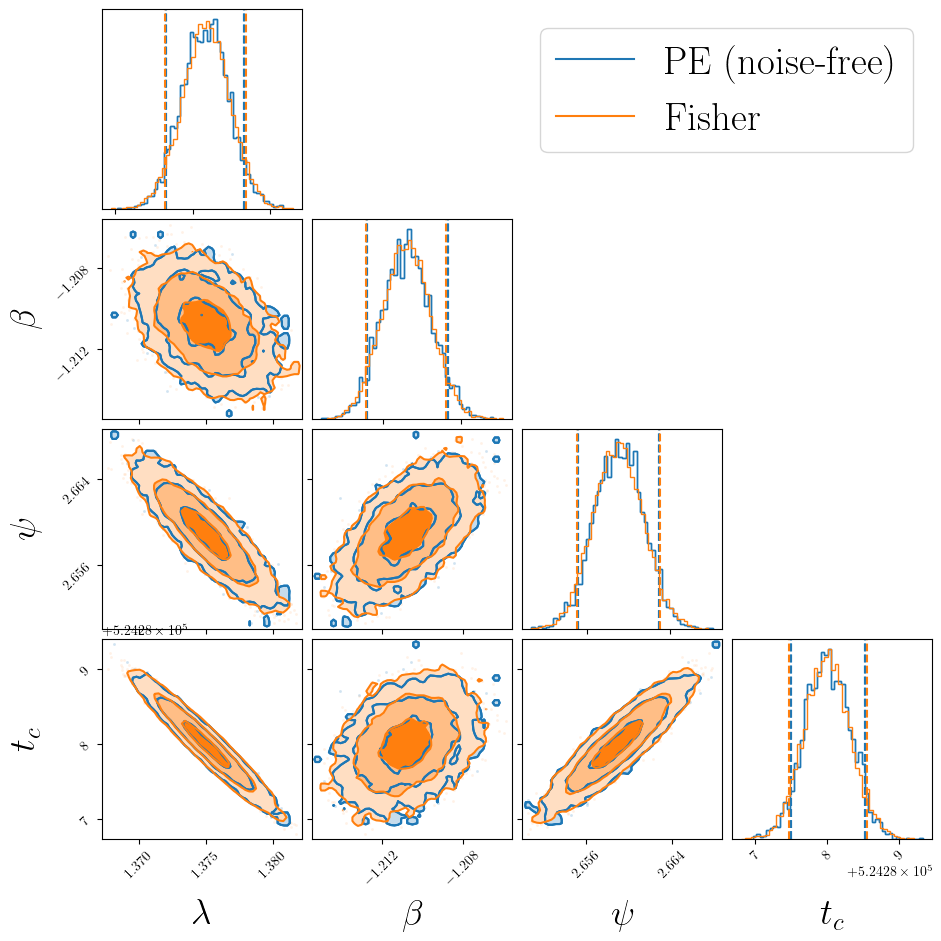

In [ ]:
fisher_res = bilby.core.result.Result(label='fisher_samples', search_parameter_keys=list(samples_pd.keys()), posterior=samples_pd)
# the posterior data can be found in https://doi.org/10.5281/zenodo.18339164
pe_res = bilby.core.result.read_in_result("intro-pespace/autodiff/pe_resp_params/outdir_extrinsic_params_LISA_noiseless/extrinsic_params_LISA_noiseless_result.json")

latex_labels = dict(
    ecliptic_longitude=r"$\lambda$", 
    ecliptic_latitude=r"$\beta$", 
    polarization=r"$\psi$", 
    coalescence_time=r"$t_c$", 
    )

fig = bilby.core.result.plot_multiple(
    [pe_res, fisher_res],
    filename="corner_fisher.pdf",
    labels=["PE (noise-free)", "Fisher"],
    titles=False,
    quantiles=[0.05, 0.95],
    corner_labels=[latex_labels[key] for key in fisher_res.search_parameter_keys],
    label_kwargs={'fontsize': 26}
    )

In [23]:
params = {
    'axes.labelsize': 18,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}',
    }
matplotlib.rcParams.update(params)

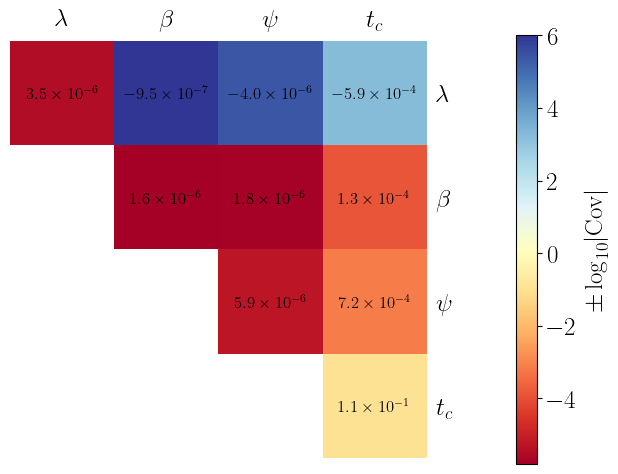

In [24]:
fig, ax = plt.subplots()

mask = np.tril(np.ones_like(cov_AET, dtype=bool), k=-1)
cov_masked = np.ma.array(cov_AET, mask=mask)
log10_cov_masked = np.sign(cov_masked) * np.log10(np.abs(cov_masked))

im = ax.imshow(log10_cov_masked, cmap="RdYlBu")

labels = [r'$\lambda$', r'$\beta$', r'$\psi$', r'$t_c$']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_label_position('top')
ax.yaxis.set_label_position('right')
ax.xaxis.tick_top()
ax.yaxis.tick_right()
ax.tick_params(
    top=False,
    right=False,
    bottom=False,
    left=False
)

cbar = plt.colorbar(im, cmap="RdYlBu", pad=0.15)
cbar.set_label(r"$\pm \log_{10} \lvert \mathrm{Cov} \rvert$")

for i in range(4):
    for j in range(i, 4):
        val = cov_AET[i, j]
        mantissa, exp = f"{val:.1e}".split('e')
        exp = int(exp)
        text = f"${mantissa}\\times10^{{{exp}}}$"
        ax.text(
            j, i,
            text,
            ha='center',
            va='center',
            fontsize=12,
            color='black'
        )
plt.tight_layout()

fig.savefig("cov.pdf")


In [25]:
cov_AET

array([[ 3.49566764e-06, -9.50811498e-07, -3.97684000e-06,
        -5.93983332e-04],
       [-9.50811498e-07,  1.56888845e-06,  1.81335752e-06,
         1.34486412e-04],
       [-3.97684000e-06,  1.81335752e-06,  5.87109893e-06,
         7.20021991e-04],
       [-5.93983332e-04,  1.34486412e-04,  7.20021991e-04,
         1.05851374e-01]])